In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# For Reading xlsx files
df = pd.read_excel('dataset.xlsx', engine='openpyxl')

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nUnique label values:", df['Label'].unique())

Shape: (26232, 19)

Column names: ['id', 'Author_Name', 'Fact_Check_Source', 'Source_Type', 'Statement', 'Eng_Trans_Statement', 'News Body', 'Eng_Trans_News_Body', 'Media_Link', 'Publish_Date', 'Fact_Check_Link', 'News_Category', 'Language', 'Region', 'Platform', 'Text', 'Video', 'Image', 'Label']

First 3 rows:
       id         Author_Name Fact_Check_Source Source_Type  \
0  BFNK_1  Shinjinee Majumder          Alt News        IFCN   
1  BFNK_2         Kalim Ahmed          Alt News        IFCN   
2  BFNK_3      Abhishek Kumar          Alt News        IFCN   

                                           Statement  \
0  फ़ैक्ट-चेक: तेलंगाना में एक रिपोर्टर ने गृह मंत...   
1  PM मोदी को UAE का सर्वोच्च नागरिक सम्मान मिलने...   
2  वायरल तस्वीर में सुप्रीम कोर्ट के जज सूर्यकांत...   

                                 Eng_Trans_Statement  \
0  Fact-check: A reporter in Telangana stopped sp...   
1  Share by stating the old video of PM Modi's hi...   
2  Supreme Court judges Suryakant and JB

In [4]:
# Drop rows that have empty values in key columns
df.dropna(subset=['Statement', 'Label'], inplace=True)

# Convert Label to numbers: 1 = real, 0 = fake
df['label'] = df['Label'].apply(lambda x: 1 if str(x).strip().lower() == 'true' else 0)

print("Total samples:", len(df))
print("Fake news samples:", (df['label'] == 0).sum())
print("Real news samples:", (df['label'] == 1).sum())

Total samples: 26232
Fake news samples: 10319
Real news samples: 15913


Average words in FAKE news: 12.7
Average words in REAL news: 12.7


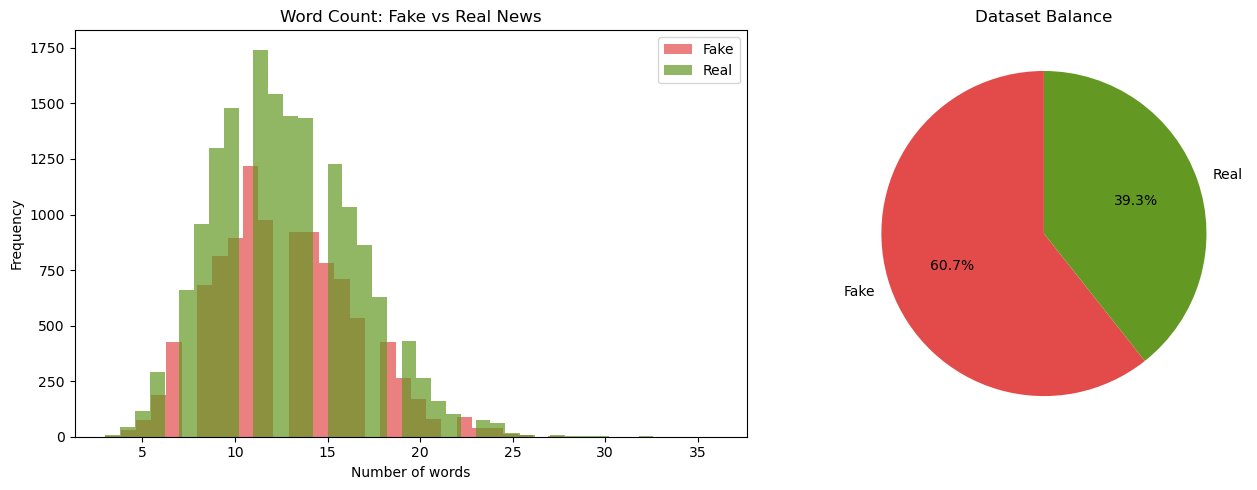

Saved: eda_chart.png


In [5]:
# Add word count column
df['word_count'] = df['Statement'].apply(lambda x: len(str(x).split()))

fake_words = df[df['label'] == 0]['word_count']
real_words = df[df['label'] == 1]['word_count']

print(f"Average words in FAKE news: {fake_words.mean():.1f}")
print(f"Average words in REAL news: {real_words.mean():.1f}")

# Plot 1: Word count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fake_words, bins=40, alpha=0.7, color='#E24B4A', label='Fake')
axes[0].hist(real_words, bins=40, alpha=0.7, color='#639922', label='Real')
axes[0].set_title('Word Count: Fake vs Real News')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot 2: Dataset balance pie chart
counts = df['label'].value_counts()
axes[1].pie(counts.values, labels=['Fake', 'Real'],
            colors=['#E24B4A', '#639922'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Dataset Balance')

plt.tight_layout()
plt.savefig('eda_chart.png', dpi=150)
plt.show()
print("Saved: eda_chart.png")

In [7]:
import sys
!{sys.executable} -m pip install wordcloud

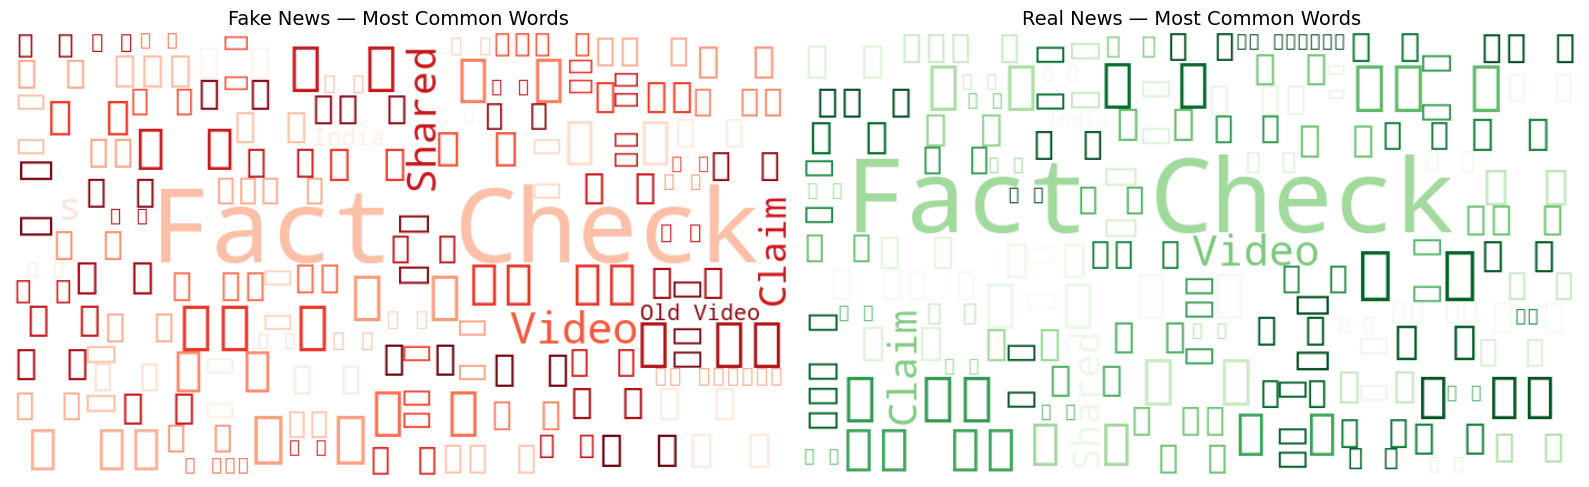

Saved: wordclouds.png


In [8]:
from wordcloud import WordCloud

# Word cloud for fake news
fake_text = ' '.join(df[df['label'] == 0]['Statement'].astype(str))
real_text = ' '.join(df[df['label'] == 1]['Statement'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_fake = WordCloud(width=700, height=400, background_color='white',
                    colormap='Reds', max_words=100,
                    regexp=r"[\w\u0900-\u097F']+").generate(fake_text)

wc_real = WordCloud(width=700, height=400, background_color='white',
                    colormap='Greens', max_words=100,
                    regexp=r"[\w\u0900-\u097F']+").generate(real_text)

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('Fake News — Most Common Words', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('Real News — Most Common Words', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()
print("Saved: wordclouds.png")

In [9]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)         # remove URLs
    text = re.sub(r'<[^>]+>', '', text)                 # remove HTML tags
    text = re.sub(r'[^\w\s\u0900-\u097F]', ' ', text)  # keep Hindi + English only
    text = re.sub(r'\s+', ' ', text).strip()            # remove extra spaces
    text = text.lower()                                  # lowercase
    return text

df['clean'] = df['Statement'].apply(clean_text)

# Show before and after
print("ORIGINAL:", df['Statement'].iloc[0])
print("\nCLEANED: ", df['clean'].iloc[0])

ORIGINAL: फ़ैक्ट-चेक: तेलंगाना में एक रिपोर्टर ने गृह मंत्री अमित शाह की बोलती बंद कर दी?

CLEANED:  फ़ैक्ट चेक तेलंगाना में एक रिपोर्टर ने गृह मंत्री अमित शाह की बोलती बंद कर दी


In [10]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    token_pattern=r"(?u)\b[\w\u0900-\u097F]{2,}\b"
)

X = tfidf.fit_transform(df['clean'])
y = df['label']

print("Feature matrix shape:", X.shape)
print(f"This means {X.shape[0]} news samples × {X.shape[1]} text features")

Feature matrix shape: (26232, 5000)
This means 26232 news samples × 5000 text features


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% training, 20% testing
    random_state=42,
    stratify=y           # keeps fake/real ratio equal in both splits
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 20985
Testing samples:  5247


In [12]:
model = RandomForestClassifier(
    n_estimators=200,        # 200 decision trees
    random_state=42,
    n_jobs=-1,               # use all CPU cores
    class_weight='balanced'  # handles unequal fake/real counts
)

print("Training... this will take 1-3 minutes, please wait...")
model.fit(X_train, y_train)
print("Training complete!")

Training... this will take 1-3 minutes, please wait...
Training complete!


In [13]:
y_pred = model.predict(X_test)
f1 = f1_score(y_test, y_pred)

print("=" * 45)
print(f"  F1-Score: {f1*100:.1f}%")
print("=" * 45)
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

  F1-Score: 69.4%
              precision    recall  f1-score   support

        Fake       0.45      0.28      0.35      2064
        Real       0.63      0.78      0.69      3183

    accuracy                           0.58      5247
   macro avg       0.54      0.53      0.52      5247
weighted avg       0.56      0.58      0.56      5247



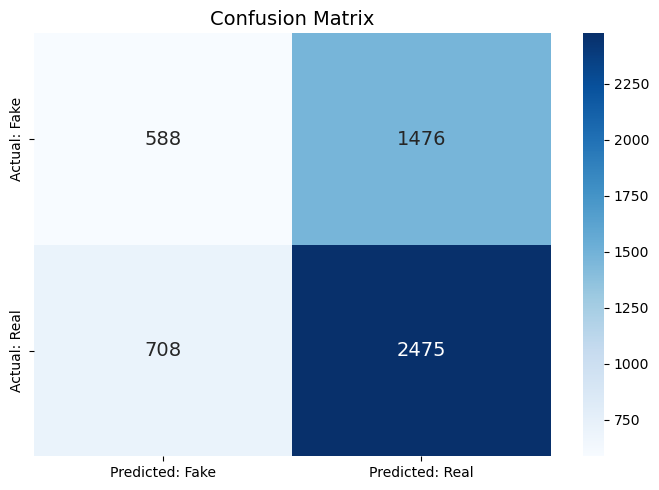

Saved: confusion_matrix.png


In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Fake', 'Predicted: Real'],
            yticklabels=['Actual: Fake', 'Actual: Real'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

In [15]:
print("Running 5-fold cross validation... (takes a few minutes)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='f1', n_jobs=-1)

print(f"\nScores per fold: {[round(s*100,1) for s in cv_scores]}")
print(f"Mean F1:         {cv_scores.mean()*100:.1f}%")
print(f"Std deviation:   ±{cv_scores.std()*100:.1f}%")
print("\nThis proves the model is consistent, not just lucky on one split.")

Running 5-fold cross validation... (takes a few minutes)

Scores per fold: [np.float64(69.3), np.float64(69.2), np.float64(69.7), np.float64(69.8), np.float64(69.2)]
Mean F1:         69.5%
Std deviation:   ±0.3%

This proves the model is consistent, not just lucky on one split.


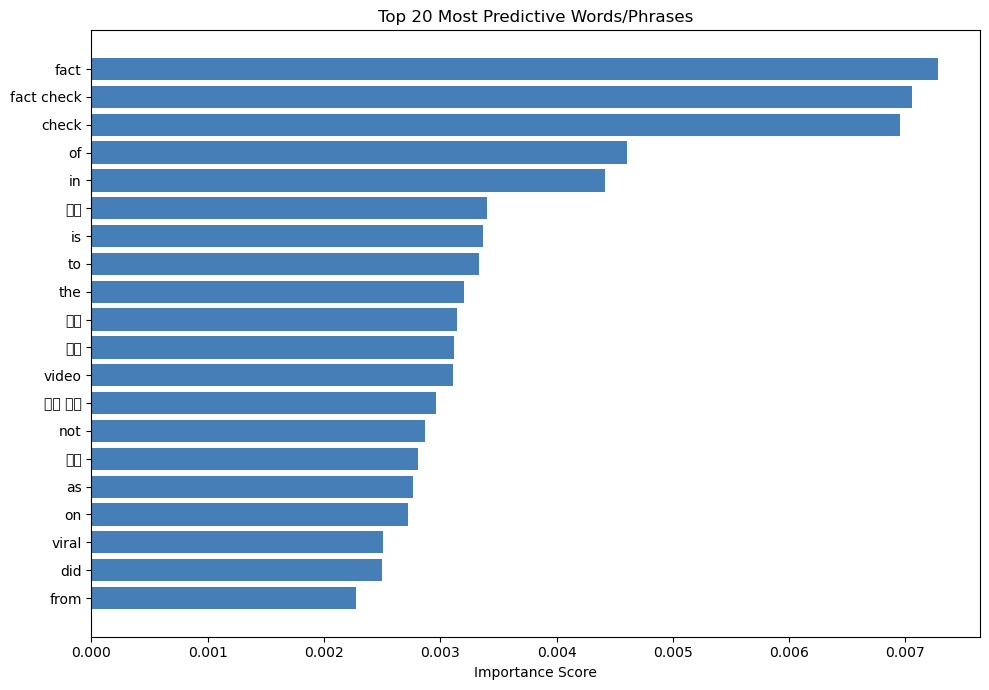

Saved: feature_importance.png


In [16]:
feature_names = tfidf.get_feature_names_out()
importances = model.feature_importances_
top_indices = np.argsort(importances)[::-1][:20]

top_features = [(feature_names[i], importances[i]) for i in top_indices]

fig, ax = plt.subplots(figsize=(10, 7))
words = [f[0] for f in top_features]
scores = [f[1] for f in top_features]

ax.barh(range(20), scores[::-1], color='#185FA5', alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels(words[::-1])
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Most Predictive Words/Phrases')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Saved: feature_importance.png")

In [17]:
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('rf_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Saved successfully!")
print("Files created:")
print("  tfidf_vectorizer.pkl")
print("  rf_model.pkl")
print("\nPhase 4 complete. Now go to Phase 5.")

Saved successfully!
Files created:
  tfidf_vectorizer.pkl
  rf_model.pkl

Phase 4 complete. Now go to Phase 5.
